In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [25]:
df = pd.read_csv('temp_change_land.csv')
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,21,Northern America,7271,Temperature change,7001,January,1961,1961,°C,0.662,E,Estimated value
1,ET,Temperature change on land,21,Northern America,7271,Temperature change,7001,January,1962,1962,°C,-0.461,E,Estimated value
2,ET,Temperature change on land,21,Northern America,7271,Temperature change,7001,January,1963,1963,°C,-0.498,E,Estimated value
3,ET,Temperature change on land,21,Northern America,7271,Temperature change,7001,January,1964,1964,°C,1.306,E,Estimated value
4,ET,Temperature change on land,21,Northern America,7271,Temperature change,7001,January,1965,1965,°C,-0.043,E,Estimated value


In [26]:
#checking dataset
df.info()

df.describe()

print("Number of rows, columns in the dataset: %d, %d" % (df.shape[0], df.shape[1]))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       2210 non-null   object 
 1   Domain            2210 non-null   object 
 2   Area Code (M49)   2210 non-null   int64  
 3   Area              2210 non-null   object 
 4   Element Code      2210 non-null   int64  
 5   Element           2210 non-null   object 
 6   Months Code       2210 non-null   int64  
 7   Months            2210 non-null   object 
 8   Year Code         2210 non-null   int64  
 9   Year              2210 non-null   int64  
 10  Unit              2210 non-null   object 
 11  Value             2210 non-null   float64
 12  Flag              2210 non-null   object 
 13  Flag Description  2210 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 241.8+ KB
Number of rows, columns in the dataset: 2210, 14


In [27]:
#check for null/ missing values and dropping 

new_df = df.copy()
new_df = new_df.dropna()
new_df.isnull().sum()


Domain Code         0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Months Code         0
Months              0
Year Code           0
Year                0
Unit                0
Value               0
Flag                0
Flag Description    0
dtype: int64

In [28]:
#check for values in the dataset
for i in new_df.columns:
    print(new_df[i].unique())

['ET']
['Temperature change on land']
[21]
['Northern America']
[7271 6078]
['Temperature change' 'Standard Deviation']
[7001 7002 7003 7004 7005 7006 7007 7008 7009 7010 7011 7012 7016 7017
 7018 7019 7020]
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December' 'Dec–Jan–Feb' 'Mar–Apr–May'
 'Jun–Jul–Aug' 'Sep–Oct–Nov' 'Meteorological year']
[1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024 2025]
[1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 

0       1961
1       1962
2       1963
3       1964
4       1965
        ... 
2140    2021
2141    2022
2142    2023
2143    2024
2144    2025
Name: Year, Length: 1105, dtype: int64


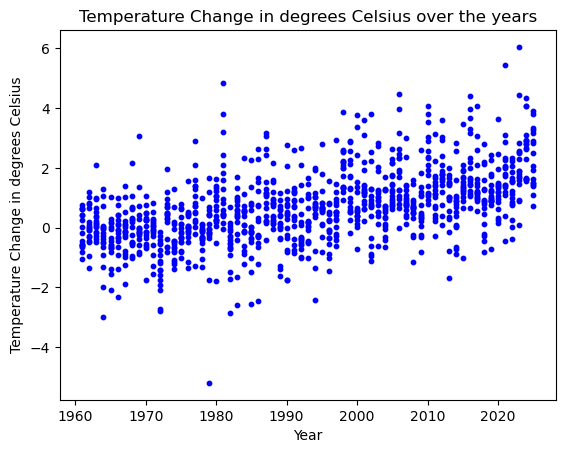

In [37]:
#create a plot for temperature change over the years 
x_values = new_df.loc[new_df['Element'] == 'Temperature change', 'Year']
y_values = new_df.loc[new_df['Element'] == 'Temperature change', 'Value']

print(x_values)

plt.scatter(x_values, y_values, s=10, color='blue')

plt.title("Temperature Change in degrees Celsius over the years")
plt.xlabel("Year")
plt.ylabel("Temperature Change in degrees Celsius")

plt.show()

In [ ]:
#mean temperature per year/ calculate rate of change between means per year
mean_temp = new_df.groupby('Year')['Value'].mean().reset_index()
mean_temp['rate of change'] = mean_temp['Value'].pct_change() * 100
mean_temp.fillna(0, inplace=True)

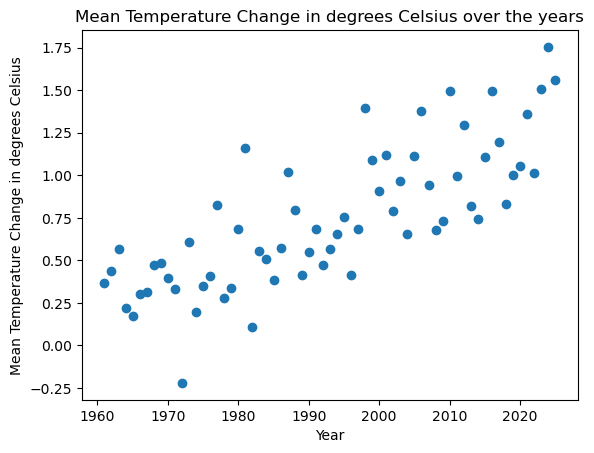

In [43]:
#mean temp graph
plt.scatter(mean_temp['Year'], mean_temp['Value'])

plt.title("Mean Temperature Change in degrees Celsius over the years")
plt.xlabel("Year")
plt.ylabel("Mean Temperature Change in degrees Celsius")

plt.show()

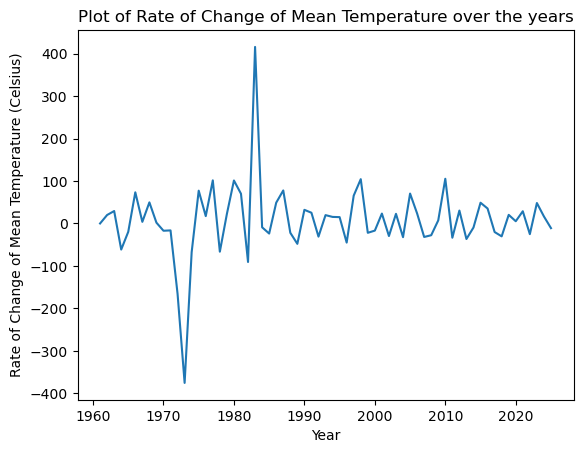

In [44]:
#Rate of Change of Mean Temperature over the years
plt.plot(mean_temp['Year'], mean_temp['rate of change'])
plt.title("Plot of Rate of Change of Mean Temperature over the years")

plt.xlabel("Year")
plt.ylabel("Rate of Change of Mean Temperature (Celsius)")

plt.show()

Text(0.5, 0, 'Temperature Change')

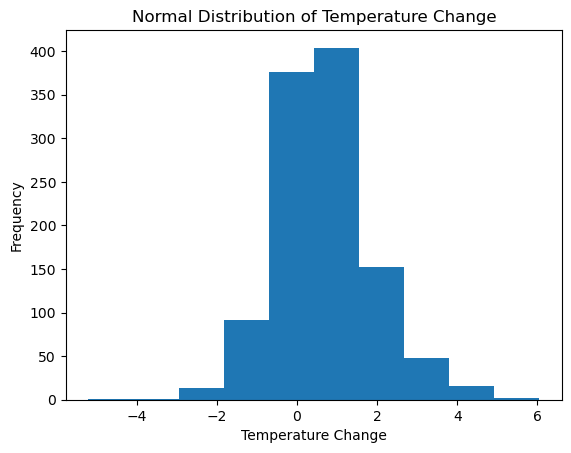

In [54]:
#check if there is a normal distribution of the data

y_values.plot(kind='hist')
plt.title('Normal Distribution of Temperature Change')
plt.xlabel('Temperature Change')

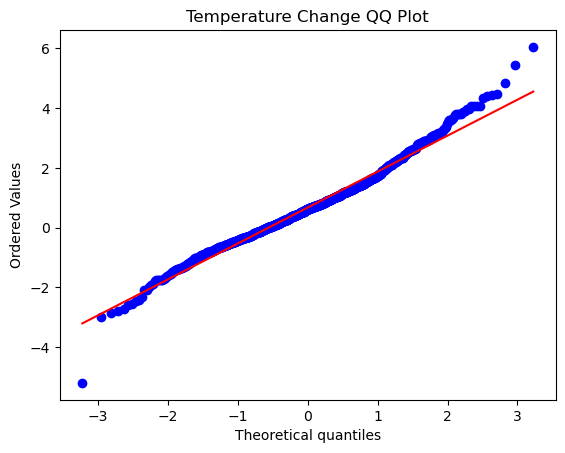

In [55]:
#Q-Q Plot
stats.probplot(y_values, dist='norm', plot=plt)
plt.title('Temperature Change QQ Plot')
plt.show()

In [ ]:
stat, p_value = stats.normaltest(y_values)

print("P-Value: ", p_value)
print("Test Stat: ", stat)

alpha = 0.05

#null hypothesis: normally distributed
#alternate hypothesis: not normally distributed

#Fail to reject null hypothestis 
if p_value > alpha:
    print('Normal Distribution')

#Reject the null hypothesis
if p_value <= alpha:
    print("Not Normal Distribution")


P-Value:  1.2636283009331205e-12
Test Stat:  54.7940678583343
Not Normal Distribution
